In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [2]:
df = pd.read_csv("/content/data.csv")

print(df.columns)
df.head()

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [3]:
no2_column = [col for col in df.columns if "NO2" in col.upper()][0]
x = df[no2_column].dropna().values.astype(float)

print("Using column:", no2_column)
print("Total samples:", len(x))

Using column: no2
Total samples: 70189


In [4]:
r = 102303412

a_r = 0.5 * (r % 7)
b_r = 0.3 * ((r % 5) + 1)

print("a_r =", a_r)
print("b_r =", b_r)

a_r = 0.5
b_r = 0.8999999999999999


In [5]:
z = x + a_r * np.sin(b_r * x)


z_mean = z.mean()
z_std = z.std()
z = (z - z_mean) / z_std

z = torch.tensor(z, dtype=torch.float32).view(-1,1)

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

G = Generator()
D = Discriminator()

In [7]:
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

batch_size = 64
epochs = 3000

In [8]:
for epoch in range(epochs):
    idx = np.random.randint(0, z.shape[0], batch_size)
    real = z[idx]

    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)


    noise = torch.randn(batch_size, 1)
    fake = G(noise)

    D_real = D(real)
    D_fake = D(fake.detach())

    loss_real = criterion(D_real, real_labels)
    loss_fake = criterion(D_fake, fake_labels)

    loss_D = loss_real + loss_fake

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()


    noise = torch.randn(batch_size, 1)
    fake = G(noise)
    D_fake = D(fake)

    loss_G = criterion(D_fake, real_labels)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")

Epoch 0 | D: 1.4095 | G: 0.5583
Epoch 500 | D: 1.1053 | G: 0.9044
Epoch 1000 | D: 1.3233 | G: 0.9084
Epoch 1500 | D: 1.4100 | G: 0.7363
Epoch 2000 | D: 1.3888 | G: 0.6847
Epoch 2500 | D: 1.3800 | G: 0.7006


In [9]:
with torch.no_grad():
    noise = torch.randn(10000, 1)
    generated = G(noise).numpy()

# De-normalize
generated = generated * z_std + z_mean
real_z = z.numpy() * z_std + z_mean

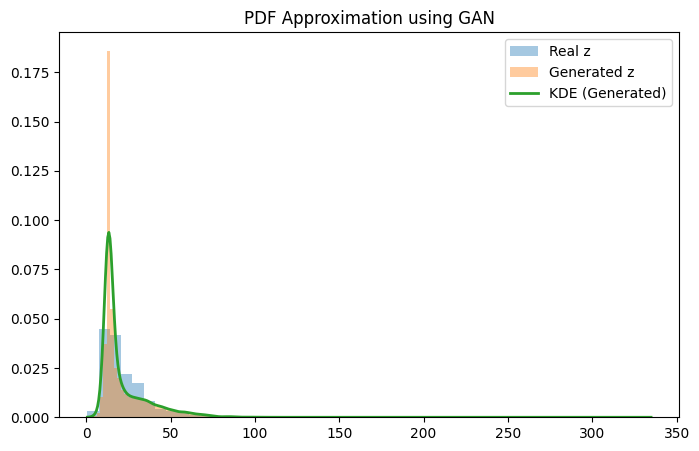

In [11]:
plt.figure(figsize=(8,5))

plt.hist(real_z, bins=50, density=True, alpha=0.4, label="Real z")
plt.hist(generated, bins=50, density=True, alpha=0.4, label="Generated z")

kde = gaussian_kde(generated.flatten())

x_range = np.linspace(real_z.min(), real_z.max(), 500)


plt.plot(x_range, kde(x_range), linewidth=2, label="KDE (Generated)")

plt.legend()
plt.title("PDF Approximation using GAN")
plt.show()